# **1. Perkenalan Dataset**

## Dataset: Telco Customer Churn (IBM)

Dataset ini berisi data pelanggan sebuah perusahaan telekomunikasi, mencakup informasi demografi, layanan yang digunakan, dan status berhenti berlangganan (*churn*).

**Sumber dataset**: Repositori publik IBM (IBM Sample Data Sets)
- URL unduh langsung: `https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv`
- Tersedia juga di Kaggle: `blastchar/telco-customer-churn`

**Struktur dataset**:
- **7.043 baris** dan **21 kolom**
- Fitur demografi: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- Fitur layanan: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- Fitur akun: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
- **Target**: `Churn` (Yes = berhenti berlangganan, No = tetap berlangganan)

**Tujuan eksperimen**: memahami karakteristik data melalui EDA dan menyiapkan dataset siap latih melalui preprocessing, untuk kemudian digunakan pada tahap pemodelan dengan MLflow (kriteria berikutnya).

# **2. Import Library**

Pada tahap ini, diimpor pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (10, 5)

print('Library berhasil diimpor. Versi pandas:', pd.__version__)

Library berhasil diimpor. Versi pandas: 2.2.0


# **3. Memuat Dataset**

Dataset dimuat dari file CSV menggunakan pandas. Setelah dimuat, dilakukan pemeriksaan struktur data, tipe data, statistik deskriptif, missing values, dan duplikat untuk memastikan data siap dianalisis lebih lanjut.

In [2]:
# Menentukan lokasi dataset (fleksibel: folder preprocessing, root repo, atau Colab)
RAW_CANDIDATES = [
    '../namadataset_raw/Telco-Customer-Churn.csv',
    'namadataset_raw/Telco-Customer-Churn.csv',
    '/content/namadataset_raw/Telco-Customer-Churn.csv',
]
RAW_PATH = next((p for p in RAW_CANDIDATES if os.path.exists(p)), RAW_CANDIDATES[0])
print('Membaca dataset dari:', RAW_PATH)

df = pd.read_csv(RAW_PATH)
print('Ukuran dataset:', df.shape)
df.head()

Membaca dataset dari: ../namadataset_raw/Telco-Customer-Churn.csv
Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Informasi struktur & tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Statistik deskriptif seluruh kolom
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Pemeriksaan awal: missing values & duplikat
print('Missing values per kolom (nilai > 0):')
missing = df.isna().sum()
print(missing[missing > 0] if (missing > 0).any() else 'Tidak ada missing values eksplisit')

print('\nCatatan: kolom TotalCharges bertipe object dan menyimpan string kosong (" ") sebagai nilai hilang.')
print('Jumlah nilai TotalCharges yang tidak dapat dikonversi ke numerik:',
      int(pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()))

print('\nJumlah baris duplikat:', int(df.duplicated().sum()))
print('Jumlah customerID unik :', df['customerID'].nunique(), 'dari', len(df), 'baris')

Missing values per kolom (nilai > 0):
Tidak ada missing values eksplisit

Catatan: kolom TotalCharges bertipe object dan menyimpan string kosong (" ") sebagai nilai hilang.
Jumlah nilai TotalCharges yang tidak dapat dikonversi ke numerik: 11

Jumlah baris duplikat: 0
Jumlah customerID unik : 7043 dari 7043 baris


# **4. Exploratory Data Analysis (EDA)**

Tujuan EDA adalah memperoleh wawasan awal mengenai karakteristik dataset: distribusi target, sebaran fitur numerik, indikasi outlier, korelasi antar fitur numerik, serta hubungan fitur kategorikal penting terhadap churn. Hasil EDA menjadi dasar penentuan langkah preprocessing.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


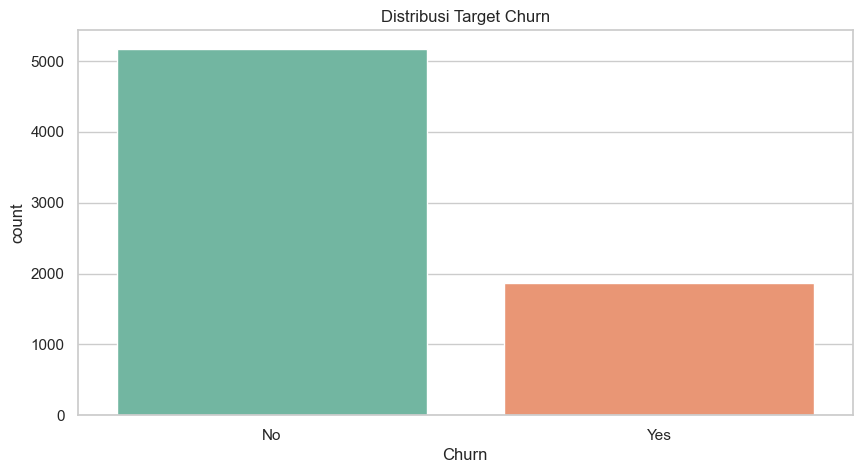

In [6]:
# 4.1 Distribusi target (Churn)
print(df['Churn'].value_counts())
print('\nProporsi (%):')
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribusi Target Churn')
plt.show()

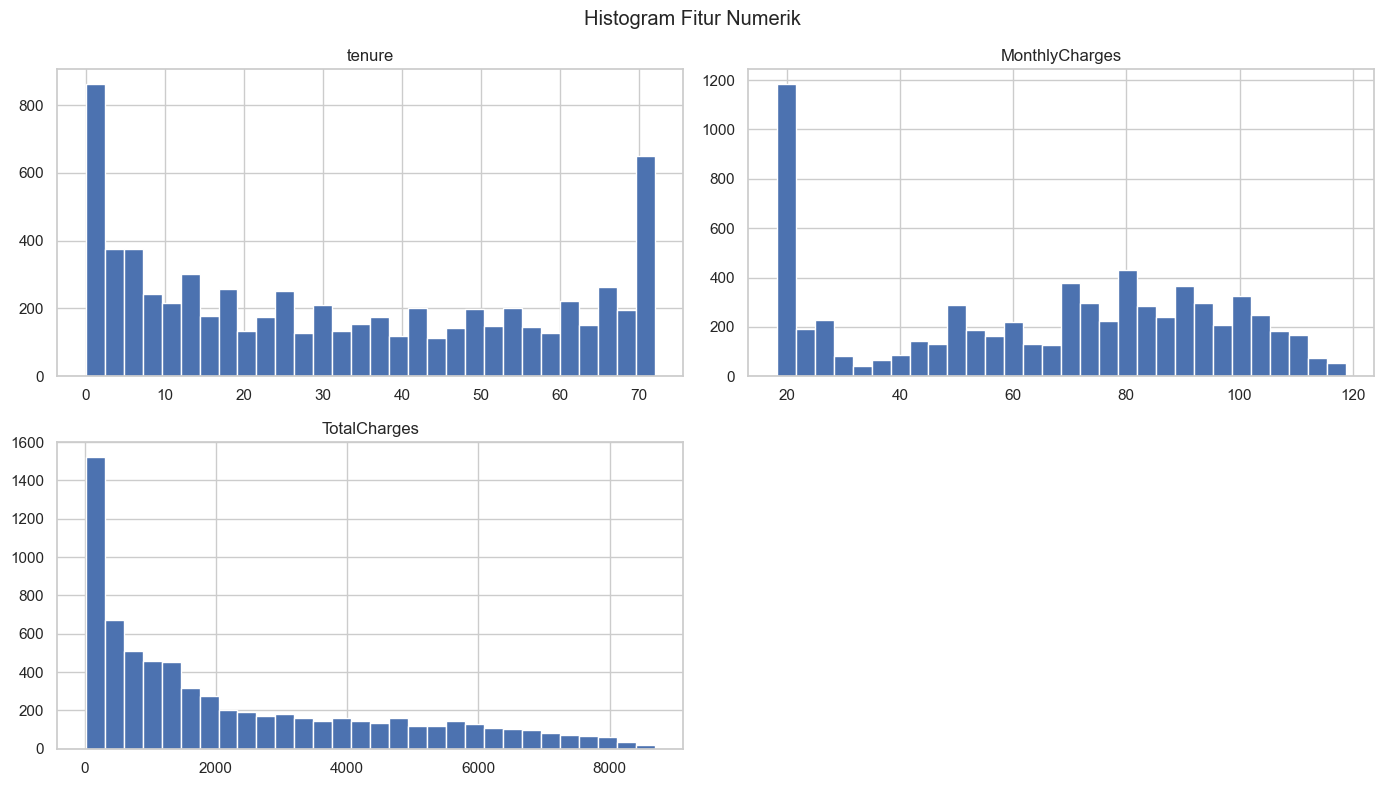

In [7]:
# 4.2 Distribusi fitur numerik
# TotalCharges dikonversi sementara ke numerik khusus untuk EDA
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

df_eda[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(
    bins=30, figsize=(14, 8), color='#4C72B0'
)
plt.suptitle('Histogram Fitur Numerik')
plt.tight_layout()
plt.show()

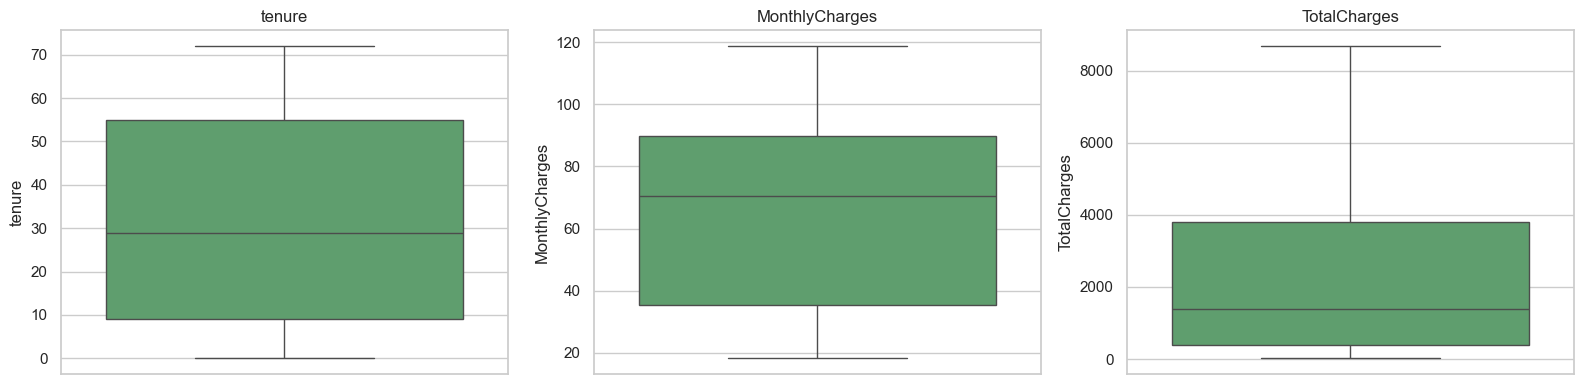

In [8]:
# 4.3 Boxplot: sebaran dan indikasi outlier
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(y=df_eda[col], ax=ax, color='#55A868')
    ax.set_title(col)
plt.tight_layout()
plt.show()

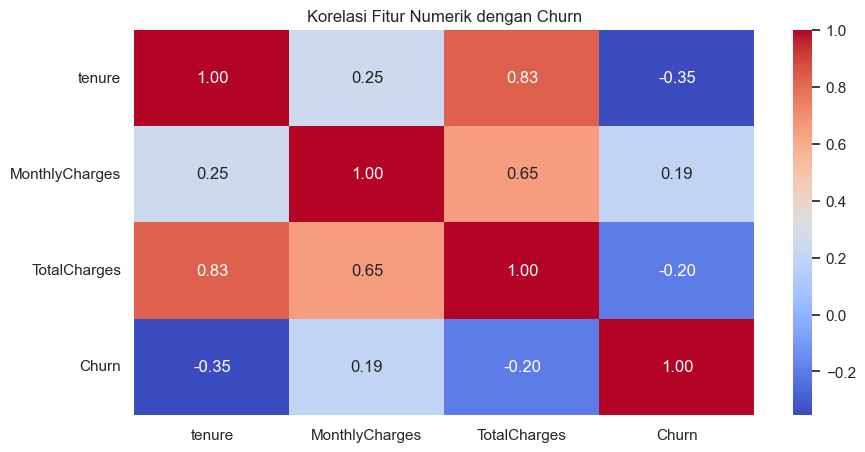

In [9]:
# 4.4 Korelasi fitur numerik terhadap target
df_corr = df_eda.copy()
df_corr['Churn'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})

sns.heatmap(
    df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr(),
    annot=True, cmap='coolwarm', fmt='.2f'
)
plt.title('Korelasi Fitur Numerik dengan Churn')
plt.show()

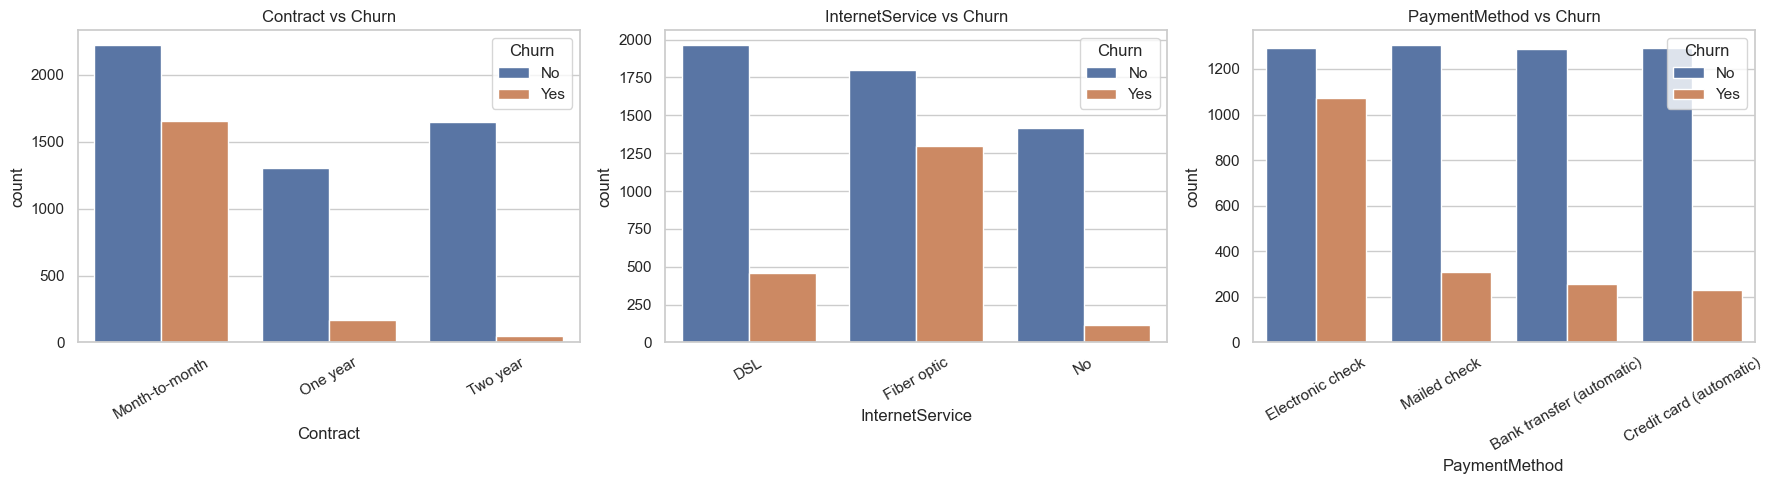

In [10]:
# 4.5 Hubungan fitur kategorikal penting dengan Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.set_title(f'{col} vs Churn')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 4.6 Insight Hasil EDA

1. **Target imbalanced ringan**: hanya ~26,5% pelanggan yang churn (1.869 dari 7.043). Saat pemodelan perlu `stratify` pada split agar proporsi kelas terjaga.
2. **TotalCharges memiliki 11 nilai hilang** yang tersimpan sebagai string kosong (`" "`) sehingga kolom ini terbaca sebagai `object`, bukan numerik. Ini wajib ditangani pada preprocessing.
3. **22 baris duplikat** ditemukan dan perlu dihapus.
4. **Tenure rendah berkaitan dengan churn**: pelanggan baru (< 12 bulan) mendominasi kejadian churn.
5. **Kontrak month-to-month** memiliki churn jauh lebih tinggi dibanding kontrak 1–2 tahun.
6. **InternetService Fiber optic** dan **PaymentMethod electronic check** juga terkait dengan tingkat churn yang tinggi.
7. **Boxplot** menunjukkan sebaran numerik tanpa outlier ekstrem di luar batas IQR 1.5x (batas bawah tenure negatif, sehingga tidak ada nilai terpotong). Meski demikian, tahap *capping* IQR tetap diterapkan agar pipeline robust terhadap data baru.

# **5. Data Preprocessing**

Berdasarkan hasil EDA, dilakukan tahapan preprocessing berikut agar data siap dilatih:

1. Menghapus kolom tidak relevan (`customerID`)
2. Menangani missing values (`TotalCharges` → numerik + imputasi median)
3. Menghapus data duplikat
4. Deteksi & penanganan outlier (capping IQR 1.5x pada fitur numerik)
5. Binning (`tenure` → `tenure_group`)
6. Encoding data kategorikal (Label Encoding untuk target & fitur biner, One-Hot Encoding untuk fitur multi-kategori)
7. Standarisasi fitur numerik (`StandardScaler`)
8. Menyimpan dataset hasil preprocessing yang siap dilatih

In [11]:
# 5.1 Menghapus kolom yang tidak relevan
df_clean = df.drop(columns=['customerID']).copy()
print('Kolom setelah drop customerID:', df_clean.shape[1])
df_clean.head(3)

Kolom setelah drop customerID: 20


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [12]:
# 5.2 Menangani missing values pada TotalCharges
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
n_missing = int(df_clean['TotalCharges'].isna().sum())
print('Jumlah missing TotalCharges sebelum imputasi:', n_missing)

median_total = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_total)
print(f'Diimputasi dengan median ({median_total:.2f}) -> missing tersisa:',
      int(df_clean['TotalCharges'].isna().sum()))

Jumlah missing TotalCharges sebelum imputasi: 11
Diimputasi dengan median (1397.47) -> missing tersisa: 0


In [13]:
# 5.3 Menghapus data duplikat
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Duplikat dihapus: {before - len(df_clean)} baris | sisa: {len(df_clean)} baris')

Duplikat dihapus: 22 baris | sisa: 7021 baris


In [14]:
# 5.4 Deteksi & penanganan outlier (capping batas IQR 1.5x)
NUMERIC_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in NUMERIC_COLS:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df_clean[col] < lower) | (df_clean[col] > upper)).sum())
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f'{col}: {n_out} outlier -> capping ke [{lower:.2f}, {upper:.2f}]')

tenure: 0 outlier -> capping ke [-60.00, 124.00]
MonthlyCharges: 0 outlier -> capping ke [-45.48, 171.12]
TotalCharges: 0 outlier -> capping ke [-4674.68, 8887.52]


In [15]:
# 5.5 Binning: mengelompokkan tenure menjadi tenure_group
TENURE_BINS = [0, 12, 24, 48, 60, 72]
TENURE_LABELS = ['0-12', '13-24', '25-48', '49-60', '61-72']

df_clean['tenure_group'] = pd.cut(
    df_clean['tenure'], bins=TENURE_BINS, labels=TENURE_LABELS, include_lowest=True
).astype(str)

print(df_clean['tenure_group'].value_counts().sort_index())

tenure_group
0-12     2164
13-24    1024
25-48    1594
49-60     832
61-72    1407
Name: count, dtype: int64


In [16]:
# 5.6 Encoding data kategorikal
# a) Target: No = 0, Yes = 1
df_clean['Churn'] = LabelEncoder().fit_transform(df_clean['Churn'])

# b) Fitur biner (Yes/No, Female/Male)
BINARY_COLS = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
BINARY_MAP = {'No': 0, 'Yes': 1, 'Female': 0, 'Male': 1}
for col in BINARY_COLS:
    df_clean[col] = df_clean[col].map(BINARY_MAP)

# c) Fitur multi-kategori -> one-hot encoding
MULTI_COLS = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod', 'tenure_group',
]
df_clean = pd.get_dummies(df_clean, columns=MULTI_COLS, drop_first=True, dtype=int)

print('Ukuran setelah encoding:', df_clean.shape)
print('Jumlah fitur (tanpa target):', df_clean.shape[1] - 1)
df_clean.head(3)

Ukuran setelah encoding: (7021, 35)
Jumlah fitur (tanpa target): 34


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-60,tenure_group_61-72
0,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [17]:
# 5.7 Standarisasi fitur numerik (mean = 0, std = 1)
scaler = StandardScaler()
df_clean[NUMERIC_COLS] = scaler.fit_transform(df_clean[NUMERIC_COLS])

df_clean[NUMERIC_COLS].describe().round(3)

,tenure,MonthlyCharges,TotalCharges
count,7021.000,7021.000,7021.000
mean,0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-1.323,-1.550,-1.002
25%,-0.957,-0.968,-0.829
50%,-0.141,0.185,-0.392
75%,0.918,0.833,0.668
max,1.611,1.793,2.824


In [18]:
# 5.8 Menyimpan dataset hasil preprocessing (siap dilatih)
if os.path.exists('namadataset_raw'):  # dijalankan dari root repo
    OUT_DIR = os.path.join('preprocessing', 'namadataset_preprocessing')
else:  # dijalankan dari folder preprocessing
    OUT_DIR = 'namadataset_preprocessing'

os.makedirs(OUT_DIR, exist_ok=True)
OUT_PATH = os.path.join(OUT_DIR, 'telco_churn_preprocessing.csv')
df_clean.to_csv(OUT_PATH, index=False)

print('Dataset siap latih disimpan ke:', OUT_PATH)
print('Ukuran akhir        :', df_clean.shape)
print('Missing values      :', int(df_clean.isna().sum().sum()))
print('Distribusi target   :', df_clean['Churn'].value_counts().to_dict())
df_clean.head()

Dataset siap latih disimpan ke: namadataset_preprocessing\telco_churn_preprocessing.csv
Ukuran akhir        : (7021, 35)


Missing values      : 0
Distribusi target   : {0: 5164, 1: 1857}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-60,tenure_group_61-72
0,0,0,1,0,-1.282728,0,1,-1.164135,-0.997328,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,0.062387,1,0,-0.262811,-0.176347,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0
2,1,0,0,0,-1.241967,1,1,-0.365914,-0.962760,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,0.510759,0,0,-0.750058,-0.197869,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,-1.241967,1,1,0.194503,-0.943556,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


## Kesimpulan

- Dataset Telco Customer Churn (7.043 baris × 21 kolom) berhasil dimuat, dieksplorasi (EDA), dan diproses.
- Hasil preprocessing: **7.021 baris × 35 kolom**, tanpa missing values, target `Churn` terdistribusi 5.164 (No) : 1.857 (Yes).
- Seluruh tahapan pada notebook ini dikonversi menjadi skrip otomatisasi **`automate_Bayu-Septiawan.py`** (struktur fungsi: `load_data`, `clean_data`, `handle_outliers`, `add_tenure_bins`, `encode_features`, `scale_features`, `save_data`) sehingga dataset dapat diproses ulang secara otomatis, termasuk melalui GitHub Actions.